# 分类模型
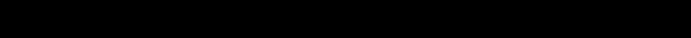
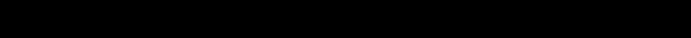

In [2]:
# 定义一个字典，将数字标签映射为对应的中文名称
classification_names = {
    0: '上身衣服',  # 数字 0 对应“上身衣服”
    1: '鞋',       # 数字 1 对应“鞋”
    2: '包',       # 数字 2 对应“包”
    3: '下身衣服',  # 数字 3 对应“下身衣服”
    4: '手表'      # 数字 4 对应“手表”
}

In [3]:
# 定义数据集加载类
import torch  # 导入 PyTorch 库，用于深度学习任务
from PIL import Image  # 导入 PIL 库中的 Image 模块，用于图像处理
import os  # 导入 os 库，用于文件和目录操作
from torch.utils.data import Dataset  # 导入 PyTorch 的 Dataset 类，用于创建自定义数据集
import torchvision.transforms as T  # 导入 torchvision 的 transforms 模块，用于图像预处理
import pandas as pd  # 导入 pandas 库，用于数据处理和分析

def sorted_alphanumeric(data):
    """按字母数字混合顺序对文件名进行排序（例如：img1, img2, ..., img10）"""
    # 定义转换函数：将数字部分转换为整数，非数字部分转换为小写
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    # 生成排序键：用正则分割字符串，分别处理数字和非数字部分
    alphanum_key = lambda key: [convert(c) for c in re.split('([0-9]+)', key)]
    # 按生成的键排序
    return sorted(data, key=alphanum_key)

# 定义自定义数据集类 ImageDataset，继承自 PyTorch 的 Dataset 类
class ImageDataset(Dataset):
    def __init__(self, main_dir, transform=None):
        """
        初始化方法。
        :param main_dir: 图像文件夹的主路径
        :param transform: 图像预处理操作（如缩放、裁剪、归一化等），默认为 None
        """
        self.main_dir = main_dir  # 存储主目录路径
        self.transform = transform  # 存储图像预处理操作
        self.all_imgs = sorted_alphanumeric(os.listdir(main_dir))  # 获取主目录下的所有图像文件名
        # 读取包含分类标签的 CSV 文件
        self.classifications = pd.read_csv('common/fashion-labels.csv')  # 从指定路径加载 CSV 文件到 DataFrame
        # 将数据类型转换为字典，提升查询效率
        self.label_dict = dict(zip(self.classifications['id'], self.classifications['target']))

    def __len__(self):
        """
        返回数据集中图像的数量。
        """
        return len(self.all_imgs)  # 返回图像文件的总数

    def __getitem__(self, idx):
        """
        根据索引 idx 获取图像及其标签。
        :param idx: 图像的索引
        :return: 预处理后的图像张量和对应的标签
        """
        # print("index: ", idx)
        img_loc = os.path.join(self.main_dir, self.all_imgs[idx])  # 获取第 idx 张图像的完整路径
        image = Image.open(img_loc).convert("RGB")  # 打开图像并将其转换为 RGB 格式
        img_flag_id = self.label_dict[idx]  # 在分类数据中查找对应的标签

        # 对图像进行预处理（如果定义了 transform）
        if self.transform is not None:
            tensor_image = self.transform(image)  # 应用预处理操作，将图像转换为张量
        else:
            raise RuntimeError("transform参数不能为None，需指定预处理方法")

        return tensor_image, img_flag_id  # 返回图像张量和标签

In [4]:
import re

# 检查是否有可用的GPU，如果有则使用GPU，否则使用CPU
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

# 定义数据预处理流程：将图像调整为64x64大小，并将其转换为Tensor
transforms = T.Compose([T.Resize((64, 64)), T.ToTensor()])

# 打印提示信息，表示正在创建数据集
print("------------ 正在创建数据集 ------------")
# 使用ImageDataset类加载数据集，数据集路径为'./image_similarity/dataset/'，并应用定义好的预处理流程
full_dataset = ImageDataset('common/dataset/', transforms)
# 计算训练集和验证集的大小，训练集占数据集的75%，验证集占剩余的25%
train_size = int(0.75 * len(full_dataset))
val_size = len(full_dataset) - train_size

# 使用random_split函数将数据集随机划分为训练集和验证集
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size]
)

# 打印提示信息，表示数据集已创建
print("------------ 数据集创建完成 ------------")

# 打印提示信息，表示正在创建DataLoader
print("------------ 创建数据加载器 ------------")

# 定义批次大小为32
batch = 32

# 创建训练集的DataLoader，批次大小为32，打乱数据顺序，并丢弃最后一个不完整的批次
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch, shuffle=True, drop_last=True
)

# 创建验证集的DataLoader，批次大小为32，不打乱数据顺序
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch
)

# 创建完整数据集的DataLoader，批次大小为32，不打乱数据顺序
full_loader = torch.utils.data.DataLoader(
    full_dataset, batch_size=batch
)

print("------------ 数据加载器创建完成 ------------")

# 遍历训练集的DataLoader，获取第一个批次的数据并打印其形状
for (x, y) in train_loader:
    print(x.shape)  # 打印输入数据的形状
    print(y.shape)  # 打印标签数据的形状
    break  # 获取第一个批次后退出循环

------------ 正在创建数据集 ------------
------------ 数据集创建完成 ------------
------------ 创建数据加载器 ------------
------------ 数据加载器创建完成 ------------
torch.Size([32, 3, 64, 64])
torch.Size([32])
